# Reverberation Artifact Characterization Report

This notebook analyzes reverberation artifacts (A-line-like horizontal bands) in an ultrasound image of a **gelatinous object inside a plastic container**.

The plastic boundaries can introduce repeated reflections, producing structured horizontal echoes that may bias downstream segmentation or reconstruction.

We document multiple characterization attempts so the notebook can serve as a technical report:
1. Fourier-domain analysis (orientation and periodicity).
2. Wavelet-based multi-scale analysis (localized repetition over depth).

Visualization strategy: interactive image review is done with Napari, and matplotlib is used mainly for summary plots (histograms, spectra, and profiles).

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import napari
from scipy import signal, ndimage
from skimage import exposure

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['image.cmap'] = 'gray'

## 1) Load NIfTI Volume and Prepare Working Image

We load the requested NIfTI file directly from the repository data folder.

The input is expected to be a 3D volume, and we extract one slice for 2D characterization.

Set `SLICE_INDEX` in the next code cell to choose a specific slice. The default is `10`.

Then we apply robust normalization (2nd to 98th percentile) to stabilize contrast without over-amplifying outliers.

In [9]:
repo_root = Path('..').resolve()
nii_path = repo_root / 'data' / 'datos enzo' / 'results' / 'vol.nii.gz'

# User-configurable slice index for 3D volumes.
SLICE_INDEX = 10

if not nii_path.exists():
    raise FileNotFoundError(f'Could not find file: {nii_path}')

vol_sitk = sitk.ReadImage(str(nii_path))
vol = sitk.GetArrayFromImage(vol_sitk).astype(np.float32)

max_idx = vol.shape[0] - 1
slice_idx = int(np.clip(SLICE_INDEX, 0, max_idx))
img = vol[slice_idx]

print(f'Loaded: {nii_path}')
print(f'Volume shape: {vol.shape}, dtype: {vol.dtype}')
print(f'Using slice index: {slice_idx} (requested: {SLICE_INDEX})')
print(f'Working image shape: {img.shape}')
print(f'Min/Max (normalized): {img.min():.3f}/{img.max():.3f}')

Loaded: C:\Users\corba\Documents\eco-root\data\datos enzo\results\vol.nii.gz
Volume shape: (30, 599, 319), dtype: float32
Using slice index: 10 (requested: 10)
Working image shape: (599, 319)
Min/Max (normalized): 0.000/252.000


Creating a single Napari viewer and adding the normalized frame...


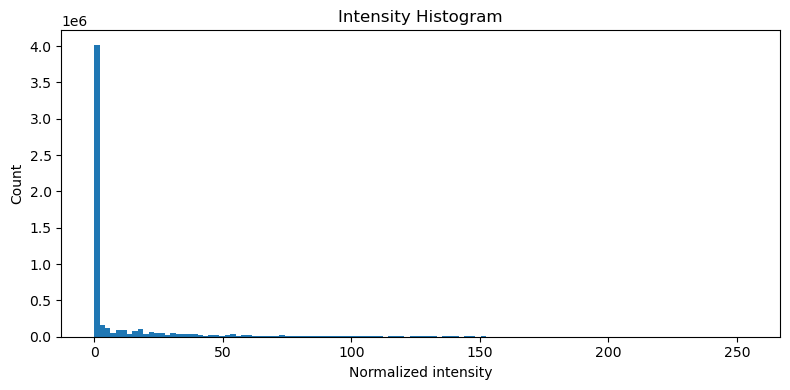

In [11]:
print('Creating a single Napari viewer and adding the normalized frame...')
viewer = napari.Viewer(title='Reverberation Artifact Exploration')
viewer.add_image(vol, name='volume', colormap='gray')

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(vol.ravel(), bins=120)
ax.set_title('Intensity Histogram')
ax.set_xlabel('Normalized intensity')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 2) Attempt A: Fourier-Domain Characterization

### Why this approach
Reverberation A-lines are approximately horizontal and often quasi-periodic in depth.
In frequency space, this should appear as structured energy at specific vertical frequencies and orientations.

### What we compute
1. A high-pass enhanced image to emphasize banding.
2. 2D FFT log-magnitude.
3. Angular power profile to identify dominant orientation.
4. 1D depth-profile spectral peak to estimate vertical spacing of repeating bands.

Adding high-pass image to the same Napari viewer...


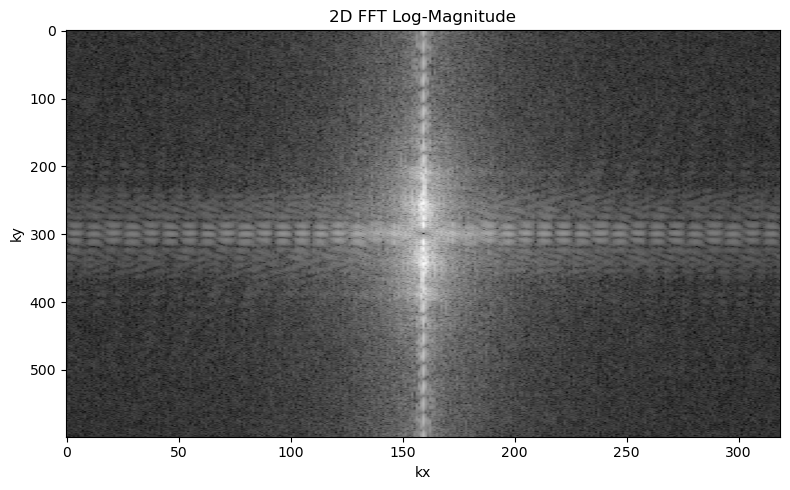

In [12]:
# Remove low-frequency background to make periodic banding more visible.
low = ndimage.gaussian_filter(img, sigma=(8, 8))
img_hp = img - low
img_hp = (img_hp - img_hp.mean()) / (img_hp.std() + 1e-8)

F = np.fft.fftshift(np.fft.fft2(img_hp))
mag = np.log1p(np.abs(F))

print('Adding high-pass image to the same Napari viewer...')
viewer.add_image(img_hp, name='img_hp', colormap='gray')

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.imshow(mag, aspect='auto')
ax.set_title('2D FFT Log-Magnitude')
ax.set_xlabel('kx')
ax.set_ylabel('ky')
plt.tight_layout()
plt.show()

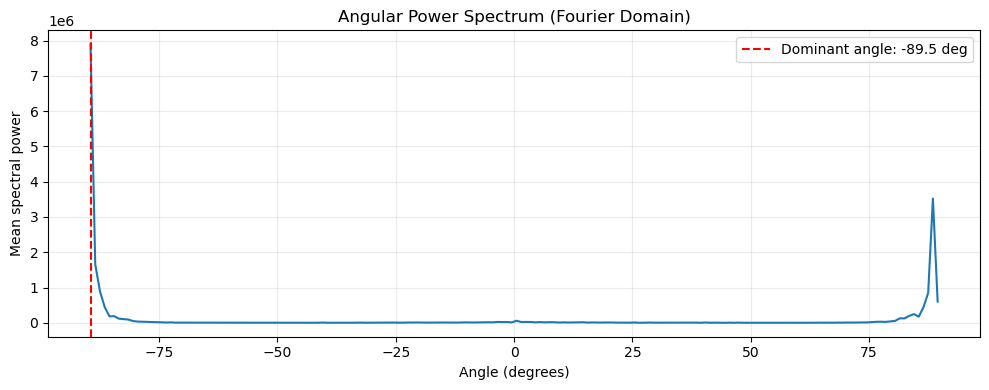

Dominant Fourier orientation: -89.50 degrees


In [13]:
h, w = img_hp.shape
cy, cx = h // 2, w // 2
yy, xx = np.indices((h, w))
ky = yy - cy
kx = xx - cx
rad = np.sqrt(kx**2 + ky**2)
ang = np.degrees(np.arctan2(ky, kx))

# Ignore very low frequencies near DC when measuring directionality.
mask = rad > min(h, w) * 0.05
angle_bins = np.linspace(-90, 90, 181)
bin_idx = np.digitize(ang[mask], angle_bins) - 1
power = np.abs(F)[mask]**2

angular_power = np.zeros(len(angle_bins) - 1, dtype=np.float64)
for i in range(len(angular_power)):
    vals = power[bin_idx == i]
    angular_power[i] = vals.mean() if vals.size else 0.0

angle_centers = (angle_bins[:-1] + angle_bins[1:]) / 2
dominant_angle = angle_centers[np.argmax(angular_power)]

plt.figure(figsize=(10, 4))
plt.plot(angle_centers, angular_power)
plt.axvline(dominant_angle, color='r', linestyle='--', label=f'Dominant angle: {dominant_angle:.1f} deg')
plt.title('Angular Power Spectrum (Fourier Domain)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Mean spectral power')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f'Dominant Fourier orientation: {dominant_angle:.2f} degrees')

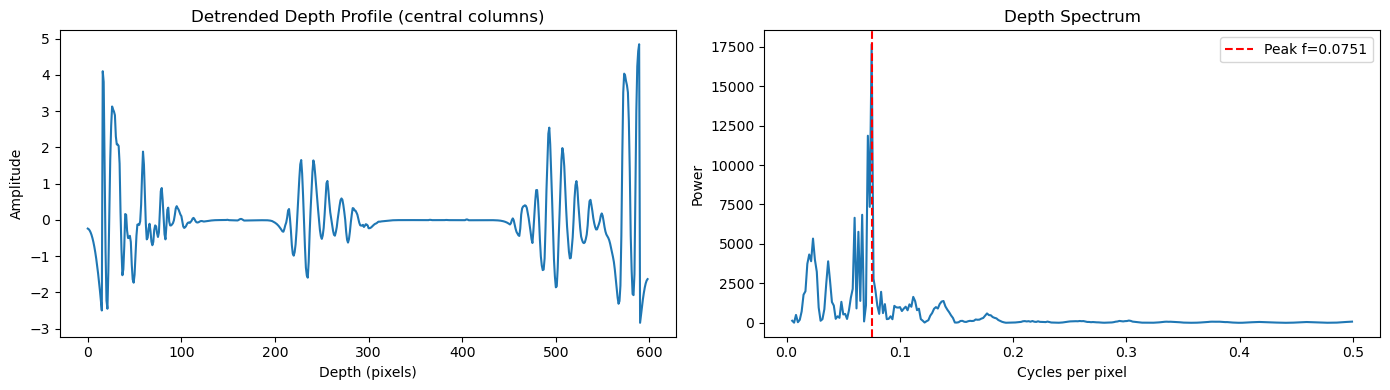

Estimated A-line spacing (Fourier): 13.31 pixels


In [6]:
# Estimate periodic depth spacing by averaging columns (A-line repetition across depth).
col_start = int(w * 0.25)
col_end = int(w * 0.75)
depth_profile = img_hp[:, col_start:col_end].mean(axis=1)
depth_profile = signal.detrend(depth_profile)

spec = np.abs(np.fft.rfft(depth_profile))**2
freq = np.fft.rfftfreq(depth_profile.size, d=1.0)

valid = (freq > 0.005) & (freq < 0.5)
peak_idx = np.argmax(spec[valid])
peak_freq = freq[valid][peak_idx]
estimated_spacing_px = (1.0 / peak_freq) if peak_freq > 0 else np.nan

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(depth_profile)
ax[0].set_title('Detrended Depth Profile (central columns)')
ax[0].set_xlabel('Depth (pixels)')
ax[0].set_ylabel('Amplitude')

ax[1].plot(freq[valid], spec[valid])
ax[1].axvline(peak_freq, color='r', linestyle='--', label=f'Peak f={peak_freq:.4f}')
ax[1].set_title('Depth Spectrum')
ax[1].set_xlabel('Cycles per pixel')
ax[1].set_ylabel('Power')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f'Estimated A-line spacing (Fourier): {estimated_spacing_px:.2f} pixels')

### Napari Review of Candidate Reverberation Bands

To complement the frequency plots, we create a simple candidate mask of horizontal reverberation bands from the high-pass image and inspect it as an overlay in Napari.

This is intentionally heuristic and meant for interactive QA rather than final segmentation.

In [14]:
# Build a simple mask of strong positive horizontal bands in the high-pass image.
col_start = int(w * 0.25)
col_end = int(w * 0.75)
band_energy = img_hp[:, col_start:col_end].mean(axis=1)
thr = band_energy.mean() + 1.2 * band_energy.std()
row_mask = band_energy > thr

artifact_mask = np.zeros_like(img, dtype=bool)
artifact_mask[row_mask, :] = True
artifact_mask = ndimage.binary_opening(artifact_mask, structure=np.ones((1, 9)))

print(f'Candidate reverberation rows: {row_mask.sum()} / {row_mask.size}')
print('Adding artifact-mask labels to the same Napari viewer...')
viewer.add_labels(
    artifact_mask.astype(np.uint8),
    name='artifact_mask',
    opacity=0.35,
 )

Candidate reverberation rows: 33 / 599
Adding artifact-mask labels to the same Napari viewer...


<Labels layer 'artifact_mask' at 0x1e6496547d0>

## 3) Attempt B: Wavelet-Based Characterization

### Why this approach
Fourier analysis gives global periodicity, but reverberation can vary with depth.
Wavelets provide **joint depth-frequency localization**, which helps identify where repetition is strongest.

### What we compute
1. A representative depth profile from central columns.
2. Continuous wavelet transform (CWT) across scales.
3. Dominant scale and an approximate reverberation spacing estimate.

Napari is used for image/overlay inspection, while matplotlib is kept for quantitative profile/spectrum plots.

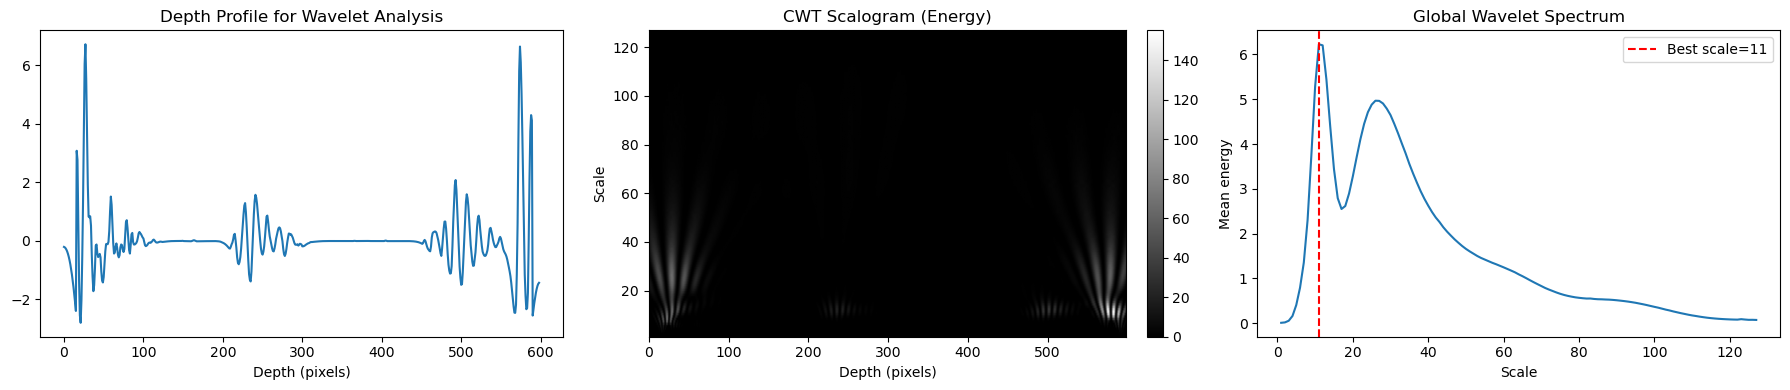

Estimated A-line spacing (Wavelet, approx): 11.00 pixels


In [15]:
try:
    import pywt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'pywavelets is required for this section. Install with: pixi add pywavelets'
    ) from exc

profile_w = img_hp[:, col_start:col_end].mean(axis=1)
profile_w = signal.detrend(profile_w)

scales = np.arange(1, 128)
coeffs, freqs_w = pywt.cwt(profile_w, scales, 'morl')
energy = np.abs(coeffs)**2
global_wavelet_spectrum = energy.mean(axis=1)

best_scale = scales[np.argmax(global_wavelet_spectrum)]
# For Morlet-like wavelets, scale is proportional to period.
estimated_spacing_wavelet_px = float(best_scale)

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(profile_w)
ax[0].set_title('Depth Profile for Wavelet Analysis')
ax[0].set_xlabel('Depth (pixels)')

im = ax[1].imshow(energy, aspect='auto', origin='lower',
                  extent=[0, profile_w.size, scales.min(), scales.max()])
ax[1].set_title('CWT Scalogram (Energy)')
ax[1].set_xlabel('Depth (pixels)')
ax[1].set_ylabel('Scale')
plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)

ax[2].plot(scales, global_wavelet_spectrum)
ax[2].axvline(best_scale, color='r', linestyle='--', label=f'Best scale={best_scale}')
ax[2].set_title('Global Wavelet Spectrum')
ax[2].set_xlabel('Scale')
ax[2].set_ylabel('Mean energy')
ax[2].legend()

plt.tight_layout()
plt.show()

print(f'Estimated A-line spacing (Wavelet, approx): {estimated_spacing_wavelet_px:.2f} pixels')

## 4) Summary and Decision Notes

### Observations to capture in your experiment log
- Fourier domain reveals global directionality and periodic structure consistent with horizontal reverberation artifacts.
- The depth-spectrum peak provides a compact estimate of spacing between repeated artifact lines.
- Wavelets reveal whether periodicity is stable or depth-dependent (localized reverberation zones).

### Practical next decisions
1. If artifact spacing is stable, design notch/band-stop suppression in vertical frequency bands.
2. If spacing varies by depth, prefer adaptive suppression (depth-dependent filters or local decomposition).
3. Keep both estimates (Fourier and wavelet) in reports to justify chosen preprocessing strategy.